To address this challenge, an image classification approach will be implemented. The provided dataset consists of images categorized into four distinct classes:

- `normal`: product surface without major defect
- `scratch`: product surface with scratch-like marks
- `dent`: product surface with circular dent-like marks
- `stain`: product surface with colored stain-like marks

Solution Architecture
These categorized images will be used to train and develop a prototype based on a Convolutional Neural Network (CNN). Once trained, this deep learning model will automatically analyze, identify, and segregate incoming images into their respective defect categories with high accuracy.

Unique classes in CSV: 4

Value counts from CSV:
 class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64
----------------------------------------
Class 'normal': 120 images found.
Class 'scratch': 120 images found.
Class 'dent': 120 images found.
Class 'stain': 120 images found.
----------------------------------------
Detected Image Dimensions: [(96, 96)]


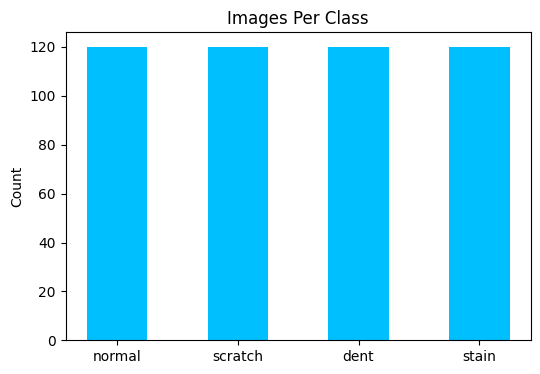

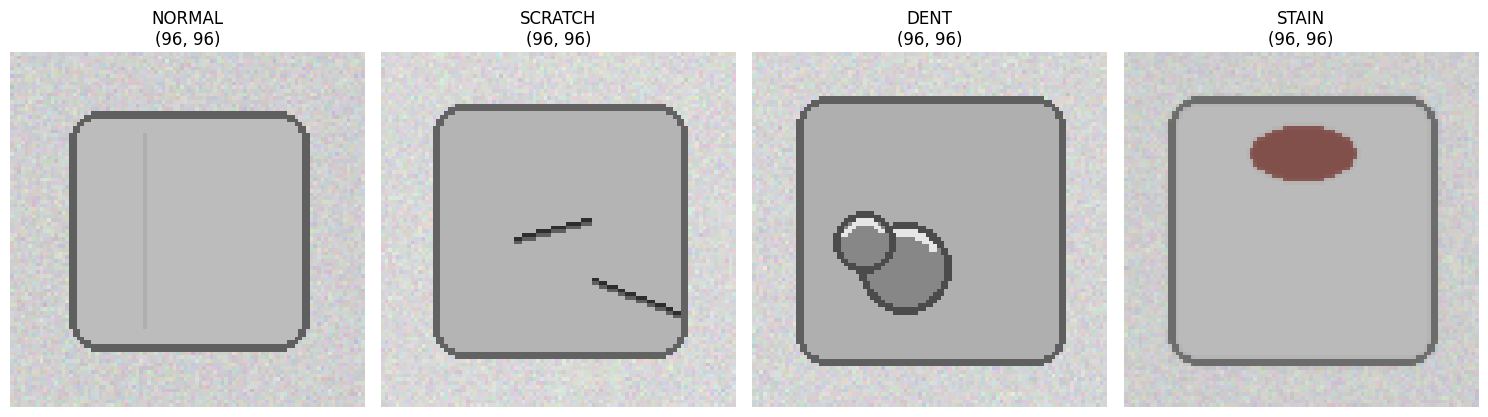

In [ ]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

df = pd.read_csv('labels.csv')

print("Unique classes in CSV:", df['class'].nunique())
print("\nValue counts from CSV:\n", df['class'].value_counts())
print("-" * 40)

normal_dir = "images/normal"
scratch_dir = "images/scratch"
dent_dir = "images/dent"
stain_dir = "images/stain"

number_classes = {
    'normal': normal_dir,
    'scratch': scratch_dir,
    'dent': dent_dir,
    'stain': stain_dir
}

image_counts = {}
unique_sizes = set()
channels = set()

for cls, folder_path in number_classes.items():
    files = [f for f in os.listdir(folder_path) if f.lower().endswith('.png')]
    image_counts[cls] = len(files)
    print(f"Class '{cls}': {len(files)} images found.")
    
    for sample_file in files[:5]:
        full_path = os.path.join(folder_path, sample_file)
        with Image.open(full_path) as img:
            unique_sizes.add(img.size) 

print("-" * 40)
print(f"Detected Image Dimensions: {list(unique_sizes)}")

plt.figure(figsize=(6, 4))
plt.bar(image_counts.keys(), image_counts.values(), width=0.5, color='deepskyblue')
plt.title("Images Per Class")
plt.ylabel("Count")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for i, (cls, folder_path) in enumerate(number_classes.items()):
    files = [f for f in os.listdir(folder_path) if f.lower().endswith('.png')]
    random_img = random.choice(files)
    
    img = Image.open(os.path.join(folder_path, random_img))
    axes[i].imshow(img)
    
    axes[i].set_title(f"{cls.upper()}\n{img.size}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)  
BASE_DIR = "images"     

train_datagen = ImageDataGenerator(
    rescale=1./255,          
    validation_split=0.2,   
    rotation_range=20,      
    width_shift_range=0.1,   
    height_shift_range=0.1,  
    horizontal_flip=True,   
    zoom_range=0.1           
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("--- Loading Training Set ---")
train_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMAGE_SIZE,  
    batch_size=BATCH_SIZE,
    class_mode='categorical', 
    subset='training',       
    shuffle=True,            
    seed=42
)

print("\n--- Loading Testing Set ---")
test_generator = test_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMAGE_SIZE,   
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',    
    shuffle=False,          
    seed=42
)

print("\n--- Verification ---")
print(f"Class Mapping indices: {train_generator.class_indices}")

--- Loading Training Set ---
Found 384 images belonging to 4 classes.

--- Loading Testing Set ---
Found 96 images belonging to 4 classes.

--- Verification ---
Class Mapping indices: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=(224, 224, 3)))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

model.add(layers.Conv2D(64, (3, 3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))


model.add(layers.Flatten())


model.add(layers.Dense(128))
model.add(layers.Activation('relu'))

model.add(layers.Dense(4))
model.add(layers.Activation('softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Saket\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,948 (49.36 MB)

 Trainable params: 12,938,948 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

--- Starting Model Training ---
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 965ms/step - accuracy: 0.2734 - loss: 2.0830 - val_accuracy: 0.2500 - val_loss: 1.3856
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2396 - loss: 1.3920 - val_accuracy: 0.2604 - val_loss: 1.3789
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2448 - loss: 1.3796 - val_accuracy: 0.3750 - val_loss: 1.3580
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.3229 - loss: 1.3400 - val_accuracy: 0.4688 - val_loss: 1.2368
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5182 - loss: 1.1255 - val_accuracy: 0.6042 - val_loss: 0.9142
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5964 - loss: 0.9123 - val_accuracy: 0.6667 - val_loss: 0.7549
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6667 - loss: 0.7622 - val_accuracy: 0.7396 - val_loss: 0.6286
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6823 - loss: 0.6877

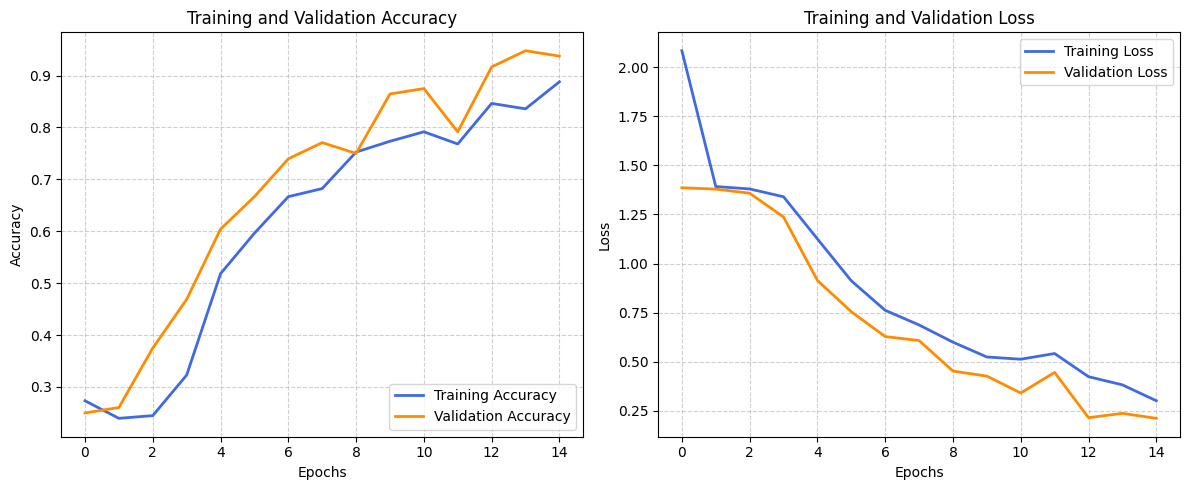


--- Evaluating Testing Performance ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 337ms/step

Classification Report:
              precision    recall  f1-score   support

        dent       0.92      0.96      0.94        24
      normal       0.89      1.00      0.94        24
     scratch       0.95      0.79      0.86        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.94        96
   macro avg       0.94      0.94      0.94        96
weighted avg       0.94      0.94      0.94        96



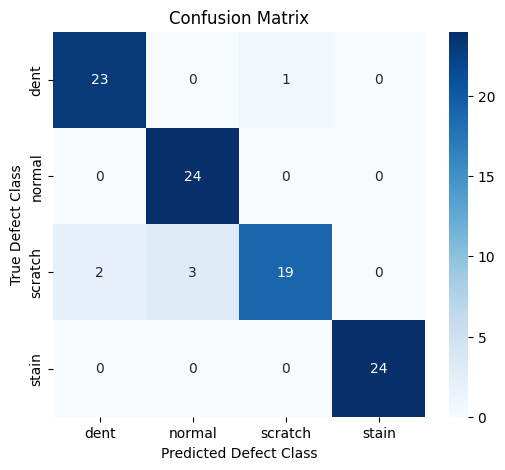

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step


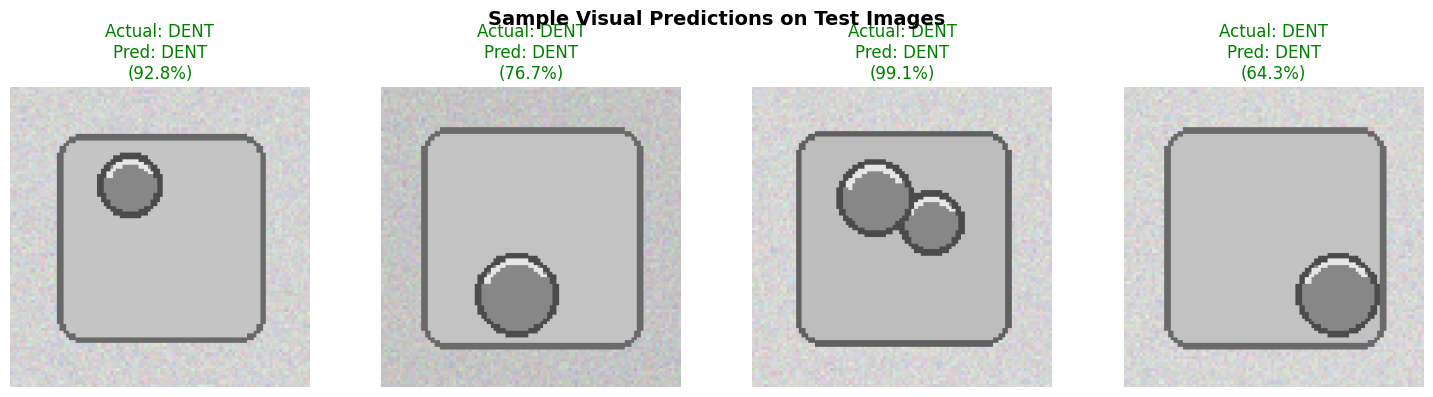

In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


EPOCHS = 15  

print("--- Starting Model Training ---")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=EPOCHS
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='royalblue', lw=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='darkorange', lw=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='royalblue', lw=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='darkorange', lw=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n--- Evaluating Testing Performance ---")
test_generator.reset()

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Defect Class')
plt.xlabel('Predicted Defect Class')
plt.show()

test_images, test_labels_onehot = next(test_generator)
true_labels_batch = np.argmax(test_labels_onehot, axis=1)

batch_predictions = model.predict(test_images)
predicted_labels_batch = np.argmax(batch_predictions, axis=1)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle("Sample Visual Predictions on Test Images", fontsize=14, weight='bold')

for i in range(4):
    axes[i].imshow(test_images[i])
    
    actual_name = class_labels[true_labels_batch[i]].upper()
    pred_name = class_labels[predicted_labels_batch[i]].upper()
    confidence = batch_predictions[i][predicted_labels_batch[i]] * 100
    
    title_color = 'green' if actual_name == pred_name else 'red'
    
    axes[i].set_title(f"Actual: {actual_name}\nPred: {pred_name}\n({confidence:.1f}%)", color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()